In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [48]:
data = pd.read_csv("student_success.csv")

In [49]:
data.head()

,age,study_hours,attendance_pct,previous_score,assignments_completed,sleep_hours,internet_quality,passed
0,21,6.59,65.1,54.0,9,7.86,Average,1
1,51,5.20,88.5,51.3,5,7.40,Good,1
2,46,1.29,81.2,88.6,2,6.92,Good,1
3,36,7.64,82.9,56.0,2,6.33,Good,0
4,36,4.11,100.0,54.4,4,4.91,Average,1


In [50]:
data.sample(10)

,age,study_hours,attendance_pct,previous_score,assignments_completed,sleep_hours,internet_quality,passed
410,25,5.58,95.7,66.9,9,6.72,Average,1
694,21,4.88,60.3,79.7,4,6.47,Poor,0
518,38,0.50,85.9,77.7,8,7.83,Poor,1
602,49,6.62,93.5,55.1,8,6.18,Good,1
841,46,4.64,74.4,47.6,7,7.82,Poor,1
805,51,5.56,81.0,69.8,4,5.33,Average,1
762,58,7.23,87.8,99.1,10,8.12,Average,1
406,36,8.78,75.7,65.2,9,6.72,Good,1
815,53,4.55,66.7,74.3,7,6.69,Good,1
206,50,2.94,57.8,71.6,6,7.51,Poor,1


In [51]:
data.columns

Index(['age', 'study_hours', 'attendance_pct', 'previous_score',
       'assignments_completed', 'sleep_hours', 'internet_quality', 'passed'],
      dtype='str')

In [52]:
columns = ['age', 'study_hours', 'attendance_pct', 'previous_score',
       'assignments_completed', 'sleep_hours', 'internet_quality', 'passed']
for col in columns:
    print(col ," : ",data[col].nunique())

age  :  43
study_hours  :  559
attendance_pct  :  364
previous_score  :  437
assignments_completed  :  9
sleep_hours  :  374
internet_quality  :  3
passed  :  2


In [53]:
data['internet_quality'] = data['internet_quality'].map({'Average':1,'Good':0,'Poor':2},dtype=int)

In [54]:
data.sample(10)

,age,study_hours,attendance_pct,previous_score,assignments_completed,sleep_hours,internet_quality,passed
817,22,5.11,73.6,79.6,10,5.21,0,1
31,27,1.84,57.2,69.8,4,5.47,0,1
254,46,4.40,58.5,66.5,8,6.72,1,1
578,56,6.37,83.2,50.1,5,5.09,0,1
336,59,4.22,78.0,73.7,2,5.85,0,1
532,24,5.25,90.3,79.6,6,9.04,0,1
799,37,4.24,79.2,66.7,10,5.29,1,1
337,31,2.56,81.4,44.5,3,5.86,2,1
780,55,4.38,84.0,63.4,6,5.74,1,1
422,50,5.57,71.2,57.3,5,6.24,0,1


In [55]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    900 non-null    int64  
 1   study_hours            900 non-null    float64
 2   attendance_pct         900 non-null    float64
 3   previous_score         900 non-null    float64
 4   assignments_completed  900 non-null    int64  
 5   sleep_hours            900 non-null    float64
 6   internet_quality       900 non-null    int64  
 7   passed                 900 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 56.4 KB


In [56]:
data.describe()

,age,study_hours,attendance_pct,previous_score,assignments_completed,sleep_hours,internet_quality,passed
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,39.206667,5.428944,77.001778,68.543889,5.900000,6.986844,0.505556,0.982222
std,12.553138,2.275994,11.561904,13.256435,2.571557,1.088176,0.652685,0.132216
min,18.000000,0.500000,45.000000,30.000000,2.000000,4.110000,0.000000,0.000000
25%,28.000000,3.867500,69.275000,59.400000,4.000000,6.230000,0.000000,1.000000
50%,39.000000,5.500000,77.800000,68.250000,6.000000,6.950000,0.000000,1.000000
75%,50.000000,6.920000,84.800000,78.000000,8.000000,7.650000,1.000000,1.000000
max,60.000000,12.000000,100.000000,100.000000,10.000000,10.000000,2.000000,1.000000


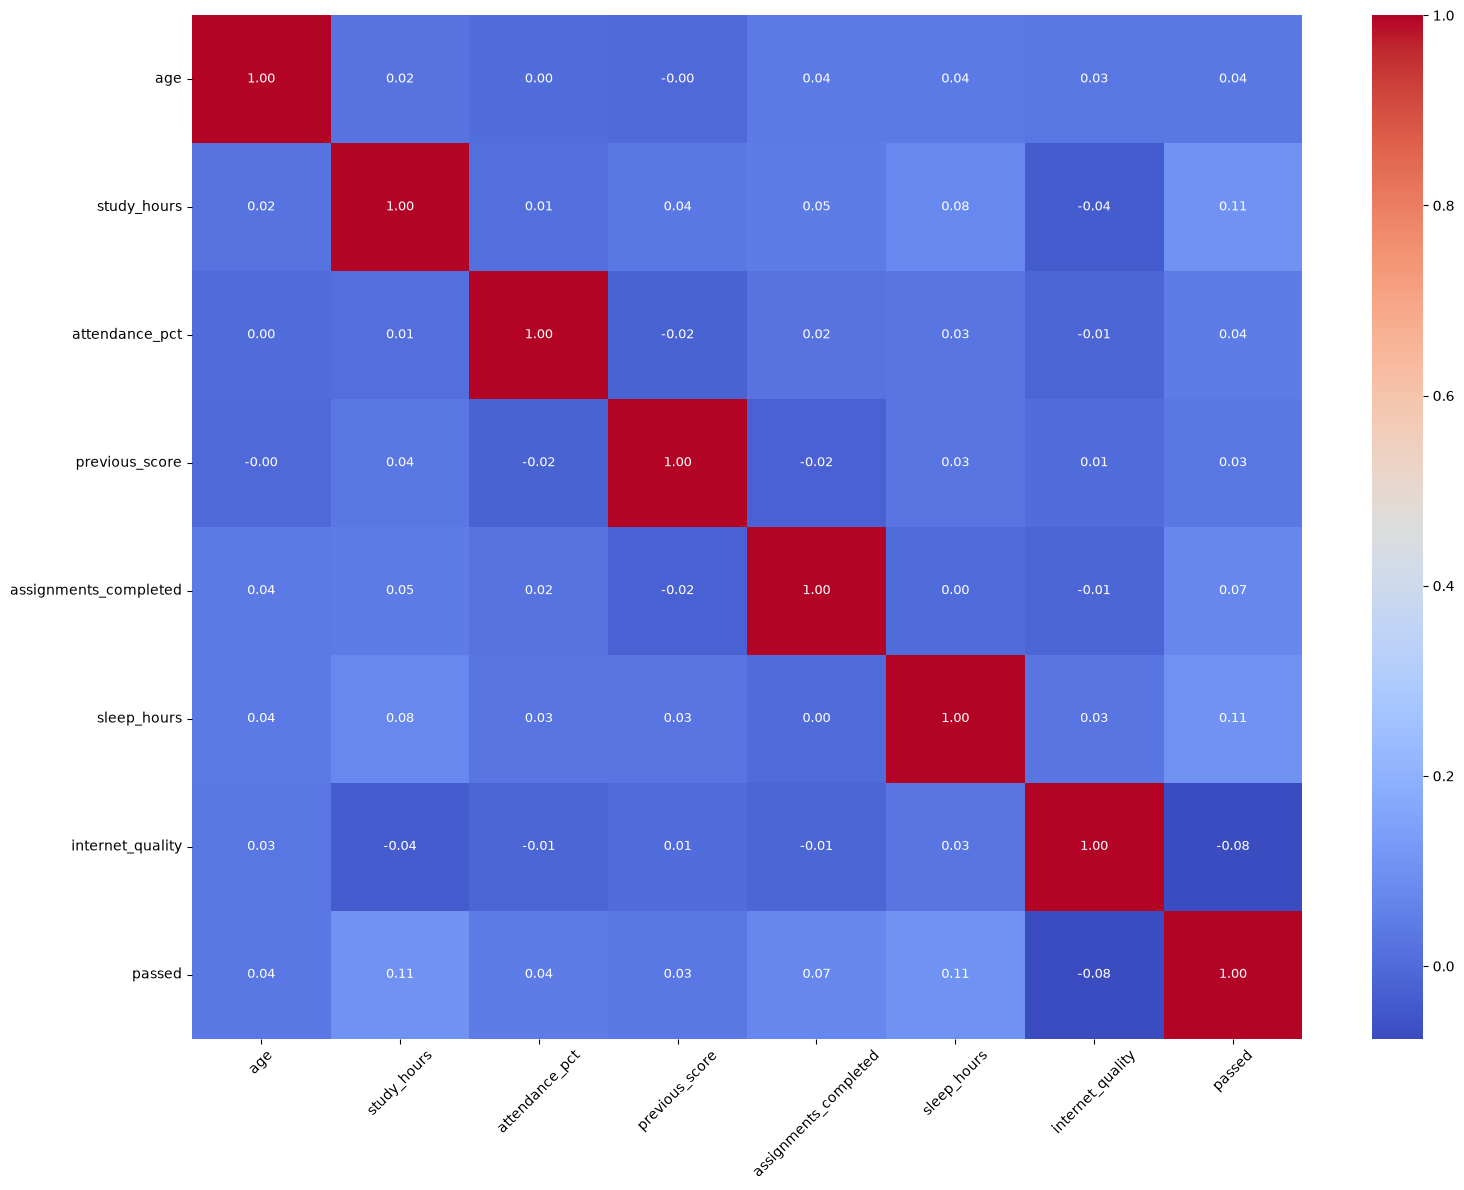

In [57]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 9}
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [59]:
from sklearn.model_selection import train_test_split

In [61]:
X = data.drop(columns="passed")
y = data['passed']

In [63]:
X.head()

,age,study_hours,attendance_pct,previous_score,assignments_completed,sleep_hours,internet_quality
0,21,6.59,65.1,54.0,9,7.86,1
1,51,5.20,88.5,51.3,5,7.40,0
2,46,1.29,81.2,88.6,2,6.92,0
3,36,7.64,82.9,56.0,2,6.33,0
4,36,4.11,100.0,54.4,4,4.91,1


In [106]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [107]:
scaler = StandardScaler()


In [114]:
X_train, X_test ,y_train,y_test = train_test_split(
    X,y , test_size=0.20,random_state=42
)


In [115]:
# from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report



In [121]:
models = {
    'logistic_Regression' :LogisticRegression(),
    'knn' : KNeighborsClassifier(n_neighbors= 7),
    'DecisionTree':DecisionTreeClassifier(),
    'navie' : GaussianNB(),
    'svm' : SVC()
}

In [122]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [123]:
result = []
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    result.append({
        'model':name,
        'Accuracy':round(acc,4),
        "f1 score":round(f1,4)
        }
    )

In [124]:
result

[{'model': 'logistic_Regression', 'Accuracy': 0.9889, 'f1 score': 0.9944},
 {'model': 'knn', 'Accuracy': 0.9889, 'f1 score': 0.9944},
 {'model': 'DecisionTree', 'Accuracy': 0.95, 'f1 score': 0.9742},
 {'model': 'navie', 'Accuracy': 0.9889, 'f1 score': 0.9944},
 {'model': 'svm', 'Accuracy': 0.9889, 'f1 score': 0.9944}]

In [126]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(name)
    print(confusion_matrix(y_test, y_pred))

logistic_Regression
[[  0   2]
 [  0 178]]
knn
[[  0   2]
 [  0 178]]
DecisionTree
[[  1   1]
 [  8 170]]
navie
[[  0   2]
 [  0 178]]
svm
[[  0   2]
 [  0 178]]


In [127]:
y.value_counts()

passed
1    884
0     16
Name: count, dtype: int64

In [136]:
from sklearn.metrics import classification_report
for name,model in models.items():
    y_pred = model.predict(X_test_scaled)
    print("\n", name)
    print(classification_report(y_test, y_pred))



 logistic_Regression
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.99      1.00      0.99       178

    accuracy                           0.99       180
   macro avg       0.49      0.50      0.50       180
weighted avg       0.98      0.99      0.98       180


 knn
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.99      1.00      0.99       178

    accuracy                           0.99       180
   macro avg       0.49      0.50      0.50       180
weighted avg       0.98      0.99      0.98       180


 DecisionTree
              precision    recall  f1-score   support

           0       0.11      0.50      0.18         2
           1       0.99      0.96      0.97       178

    accuracy                           0.95       180
   macro avg       0.55      0.73      0.58       180
weighted avg       0.98      0.

c:\Users\inzam\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\inzam\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\inzam\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [137]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [138]:
print(y_train.value_counts())
print(y_test.value_counts())

passed
1    707
0     13
Name: count, dtype: int64
passed
1    177
0      3
Name: count, dtype: int64


In [139]:
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[ 0.93979256, -0.61375298,  0.41514867, ...,  0.42540461,
         0.66127623,  0.77202752],
       [-0.34113625, -1.3837802 ,  0.29341907, ...,  0.42540461,
         1.33655565, -0.77202752],
       [ 1.50019891,  0.28535393,  0.73686262, ...,  1.5914883 ,
        -0.05151871, -0.77202752],
       ...,
       [-0.18102015, -1.15232693,  0.29341907, ...,  1.5914883 ,
        -2.67760535,  0.77202752],
       [ 1.09990866, -1.92680517, -1.40210041, ...,  0.42540461,
         0.05164898, -0.77202752],
       [ 0.45944426,  0.30315803, -0.17610941, ...,  1.5914883 ,
         0.32363652,  0.77202752]], shape=(180, 7))

In [141]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.98      1.00      0.99       177

    accuracy                           0.98       180
   macro avg       0.49      0.50      0.50       180
weighted avg       0.97      0.98      0.98       180



c:\Users\inzam\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\inzam\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\inzam\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [142]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [144]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train_scaled,
    y_train
)

In [146]:
print(y_train.value_counts())
print(y_train_resampled.value_counts())

passed
1    707
0     13
Name: count, dtype: int64
passed
1    707
0    707
Name: count, dtype: int64


In [147]:
model.fit(X_train_resampled, y_train_resampled)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [148]:
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.98      0.98      0.98       177

    accuracy                           0.96       180
   macro avg       0.49      0.49      0.49       180
weighted avg       0.97      0.96      0.96       180

